In [3]:
words = open('names.txt', 'r').read().splitlines()

In [7]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [8]:
len(words)

32033

In [9]:
min(len(w)for w in words)

2

In [11]:
max(len(w)for w in words)

15

in this exercise I am learning how to navigate VSCode without using a trackpad at all so that I can build things efficiently.

lets look at these bigrams, specifically a bigram is two characters in a row

In [31]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) +1 # in this line we are trying to see statistically how many times each character comes up. 

In [41]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

It will be incredibly more effecient to store this information in a 2D array than a python dict. Rows will be first character and columns will be the second character and each entry into the array will tell us how often the second follows the first. 

In [ ]:
import torch # will use torch to make multidimensional arrays

In [52]:
a = torch.zeros((3,5), dtype = torch.int32) # 3x5 array
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [53]:
a[1,3] = 1
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

Now for the bigram. We have 26 letters in the alphabet and also two seperate characters showing the beginning and end of the word so we will need a 28x28 matrix

In [ ]:
import torch

In [54]:
N = torch.zeros((28,28), dtype=torch.int32)

In [67]:
# we have these characters that are strings but now we need a lookup 
# table to go from characters to intergers

chars = sorted(list(set(''.join(words))))
stoi = {s:i for i,s in enumerate(chars)}
stoi['<S>'] = 26
stoi['<E>'] = 27

In [70]:

for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

N

tensor([[ 1668,  1623,  1410,  3126,  2076,   402,   504,  6996,  4950,   525,
          1704,  7584,  4902, 16314,   189,   246,   180,  9792,  3354,  2061,
          1143,  2502,   483,   546,  6150,  1305,     0, 19920],
        [  963,   114,     3,   195,  1965,     0,     0,   123,   651,     3,
             0,   309,     0,    12,   315,     0,     0,  2526,    24,     6,
           135,     0,     0,     0,   249,     0,     0,   342],
        [ 2445,     0,   126,     3,  1653,     0,     6,  1992,   813,     9,
           948,   348,     0,     0,  1140,     3,    33,   228,    15,   105,
           105,     0,     0,     9,   312,    12,     0,   291],
        [ 3909,     3,     9,   447,  3849,    15,    75,   354,  2022,    27,
             9,   180,    90,    93,  1134,     0,     3,  1272,    87,    12,
           276,    51,    69,     0,   951,     3,     0,  1548],
        [ 2037,   363,   459,  1152,  3813,   246,   375,   456,  2454,   165,
           534,  9744,  2

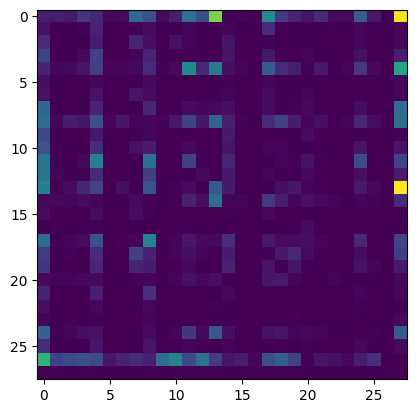

In [71]:
import matplotlib.pyplot as plt
%matplotlib inline 
plt.imshow(N)